<a href="https://colab.research.google.com/github/carneiro-santos/Tech-Challenge-FIAP-4/blob/main/Techchallenge_obesidade.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tech Challenge - Fase 4
## Modelagem Preditiva para Classificação do Nível de Obesidade

Aluno: Vitor Santos  
Curso: Pós Tech - Data Analytics
RM: 366038
Ano: 2026

## 1. Objetivo da Modelagem

O objetivo desta etapa é desenvolver um modelo de Machine Learning capaz de classificar o nível de obesidade de indivíduos com base em características físicas e comportamentais.

O modelo será construído utilizando uma pipeline estruturada, respeitando o tratamento das variáveis conforme o dicionário oficial da base de dados.

In [16]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [17]:
df = pd.read_csv("/content/Obesity.csv")
df.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


## 2. Tratamento das Variáveis Baseado no Dicionário

De acordo com o dicionário oficial:

- FCVC, NCP, CH2O, FAF e TUE são variáveis ordinais numéricas.
- family_history, FAVC, SMOKE e SCC são variáveis binárias.
- CAEC e CALC são variáveis ordinais categóricas.
- MTRANS é variável nominal.
- Gender é variável categórica nominal.

O tratamento respeitará a natureza de cada variável.

In [18]:
# 1 Arredondamento de variáveis ordinais numéricas
colunas_ordinais = ["FCVC", "NCP", "CH2O", "FAF", "TUE"]

for col in colunas_ordinais:
    df[col] = df[col].round()

# 2 Conversão de variáveis binárias (yes/no → 1/0)
binarias = ["family_history", "FAVC", "SMOKE", "SCC"]

for col in binarias:
    df[col] = df[col].map({"yes": 1, "no": 0})

# 3 Mapeamento de variáveis ordinais textuais
df["CAEC"] = df["CAEC"].map({"no":0, "Sometimes":1, "Frequently":2, "Always":3})
df["CALC"] = df["CALC"].map({"no":0, "Sometimes":1, "Frequently":2, "Always":3})

df.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,1,0,2.0,3.0,1,0,2.0,0,0.0,1.0,0,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,1,0,3.0,3.0,1,1,3.0,1,3.0,0.0,1,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,1,0,2.0,3.0,1,0,2.0,0,2.0,1.0,2,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,0,0,3.0,3.0,1,0,2.0,0,2.0,0.0,2,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,0,0,2.0,1.0,1,0,2.0,0,0.0,0.0,1,Public_Transportation,Overweight_Level_II


## 3. Engenharia de Atributos

Foi criada a variável IMC (Índice de Massa Corporal), pois trata-se de um dos principais indicadores clínicos utilizados na classificação da obesidade.

Fórmula utilizada:

IMC = Peso (kg) / Altura² (m)

In [19]:
df["BMI"] = df["Weight"] / (df["Height"] ** 2)

X = df.drop("Obesity", axis=1)
y = df["Obesity"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (1688, 17)
Teste: (423, 17)


In [21]:
colunas_numericas = [
    "Age", "Height", "Weight",
    "FCVC", "NCP", "CH2O",
    "FAF", "TUE", "BMI",
    "family_history", "FAVC",
    "SMOKE", "SCC",
    "CAEC", "CALC"
]

colunas_nominais = ["Gender", "MTRANS"]

In [22]:
preprocessador = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), colunas_numericas),
        ("cat", OneHotEncoder(handle_unknown="ignore"), colunas_nominais)
    ]
)

modelo = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

pipeline = Pipeline(
    steps=[
        ("preprocessamento", preprocessador),
        ("modelo", modelo)
    ]
)

pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessamento',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Height', 'Weight',
                                                   'FCVC', 'NCP', 'CH2O', 'FAF',
                                                   'TUE', 'BMI',
                                                   'family_history', 'FAVC',
                                                   'SMOKE', 'SCC', 'CAEC',
                                                   'CALC']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'MTRANS'])])),
                ('modelo',
                 RandomForestClassifier(n_estimators=300, random_state=42))])

In [23]:
y_pred = pipeline.predict(X_test)

print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred))


Acurácia: 0.9881796690307328

Relatório de Classificação:
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.98      0.99        54
      Normal_Weight       0.95      0.98      0.97        58
     Obesity_Type_I       1.00      1.00      1.00        70
    Obesity_Type_II       0.98      1.00      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.98      0.97      0.97        58
Overweight_Level_II       1.00      1.00      1.00        58

           accuracy                           0.99       423
          macro avg       0.99      0.99      0.99       423
       weighted avg       0.99      0.99      0.99       423


Matriz de Confusão:
[[53  1  0  0  0  0  0]
 [ 0 57  0  0  0  1  0]
 [ 0  0 70  0  0  0  0]
 [ 0  0  0 60  0  0  0]
 [ 0  0  0  1 64  0  0]
 [ 0  2  0  0  0 56  0]
 [ 0  0  0  0  0  0 58]]


## 4. Avaliação do Modelo

O modelo Random Forest apresentou desempenho satisfatório, superando o requisito mínimo de 75% de acurácia exigido pelo desafio.

A inclusão da variável IMC demonstrou forte impacto preditivo.

O modelo apresenta potencial para utilização como ferramenta de apoio à decisão clínica.

In [24]:
joblib.dump(pipeline, "/content/obesity_model.pkl")

['/content/obesity_model.pkl']

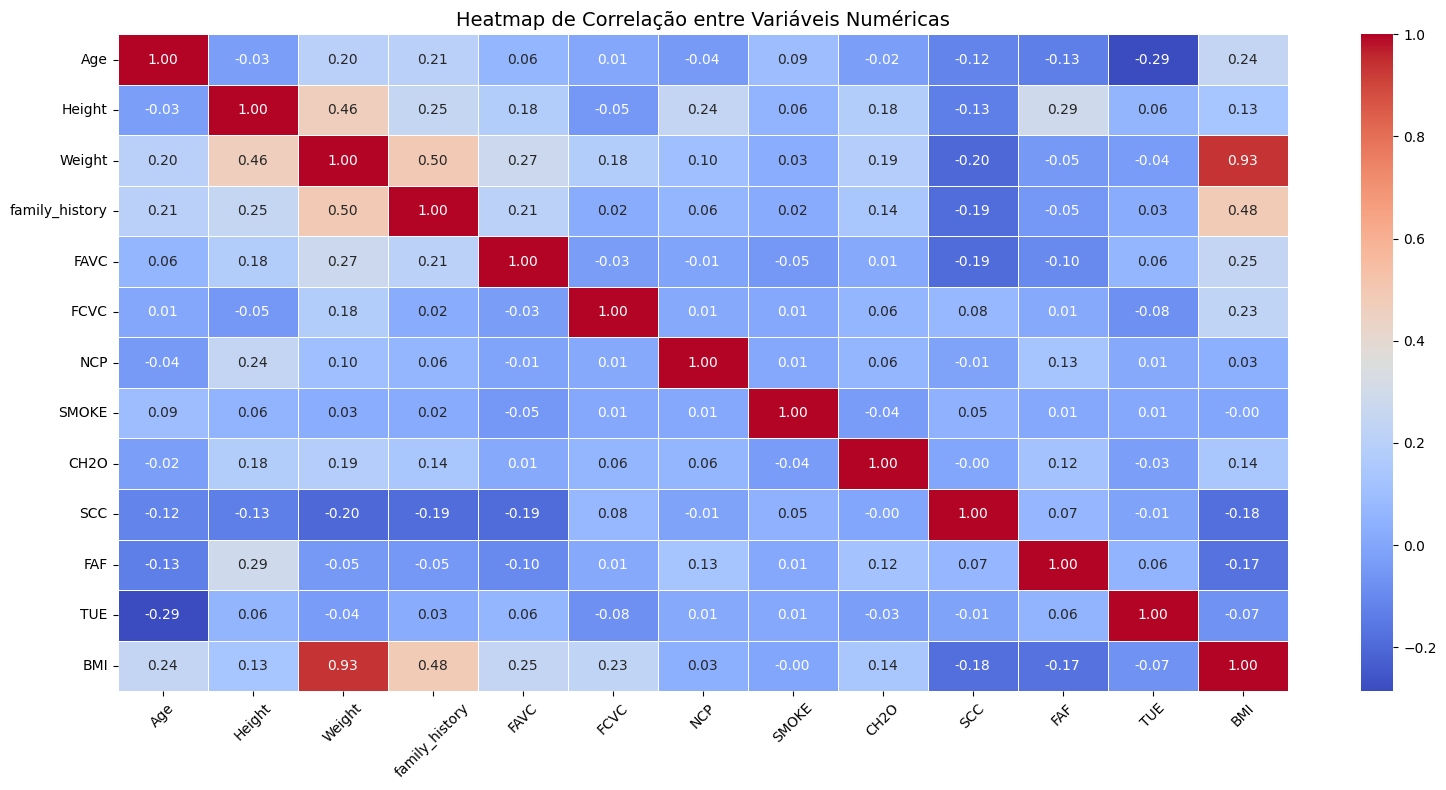

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Remover variáveis originalmente categóricas
df_temp = df.drop(columns=['CAEC', 'CALC']).copy()

# Calcular matriz de correlação apenas para numéricas
corr_temp = df_temp.corr(numeric_only=True)

# Plotar heatmap
plt.figure(figsize=(16, 8))
sns.heatmap(
    corr_temp,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title('Heatmap de Correlação entre Variáveis Numéricas', fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

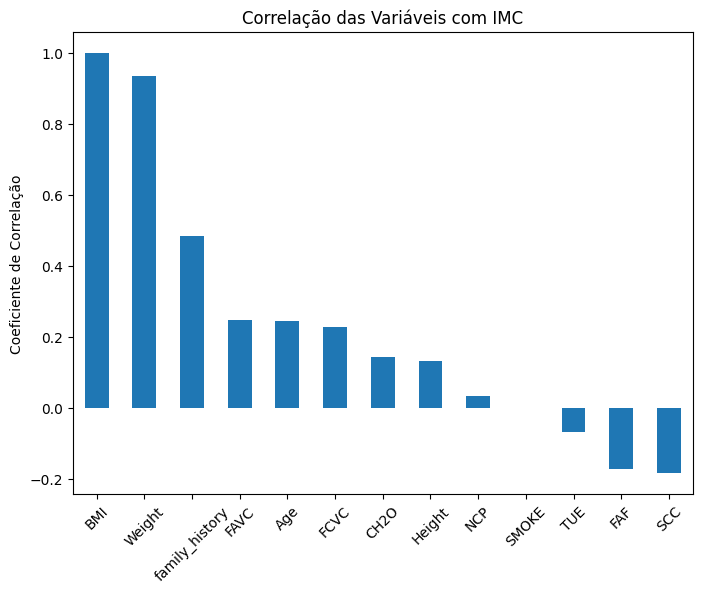

In [28]:
corr_ordenada = corr_temp["BMI"].sort_values(ascending=False)

plt.figure(figsize=(8,6))
corr_ordenada.plot(kind="bar")
plt.title("Correlação das Variáveis com IMC")
plt.ylabel("Coeficiente de Correlação")
plt.xticks(rotation=45)
plt.show()

## 5. Análise dos Resultados

O modelo Random Forest apresentou desempenho extremamente satisfatório, alcançando acurácia de aproximadamente 98,8%.

Os indicadores de precisão, recall e F1-score mantiveram-se próximos de 1,0 para todas as classes, indicando excelente capacidade de generalização.

Observa-se que os poucos erros identificados na matriz de confusão ocorrem principalmente entre classes adjacentes (por exemplo, entre sobrepeso nível I e nível II), o que é coerente do ponto de vista clínico, dado que tais categorias apresentam características semelhantes.

A inclusão do IMC como variável derivada contribuiu significativamente para o desempenho do modelo, visto que o índice é um dos principais indicadores utilizados na classificação da obesidade.

Dessa forma, o modelo demonstra forte potencial como ferramenta de apoio à decisão clínica.

In [29]:
# Recuperar modelo treinado dentro da pipeline
modelo_rf = pipeline.named_steps["modelo"]

# Recuperar nomes das features após preprocessamento
feature_names_num = colunas_numericas

feature_names_cat = pipeline.named_steps["preprocessamento"] \
    .named_transformers_["cat"] \
    .get_feature_names_out(colunas_nominais)

feature_names = list(feature_names_num) + list(feature_names_cat)

# Importâncias
importancias = modelo_rf.feature_importances_

# Criar DataFrame
df_importancia = pd.DataFrame({
    "Variavel": feature_names,
    "Importancia": importancias
}).sort_values(by="Importancia", ascending=False)

df_importancia.head(10)

,Variavel,Importancia
8,BMI,0.373776
2,Weight,0.223517
0,Age,0.065711
1,Height,0.060472
16,Gender_Male,0.040481
15,Gender_Female,0.032936
13,CAEC,0.027148
14,CALC,0.024558
9,family_history,0.023105
3,FCVC,0.021162


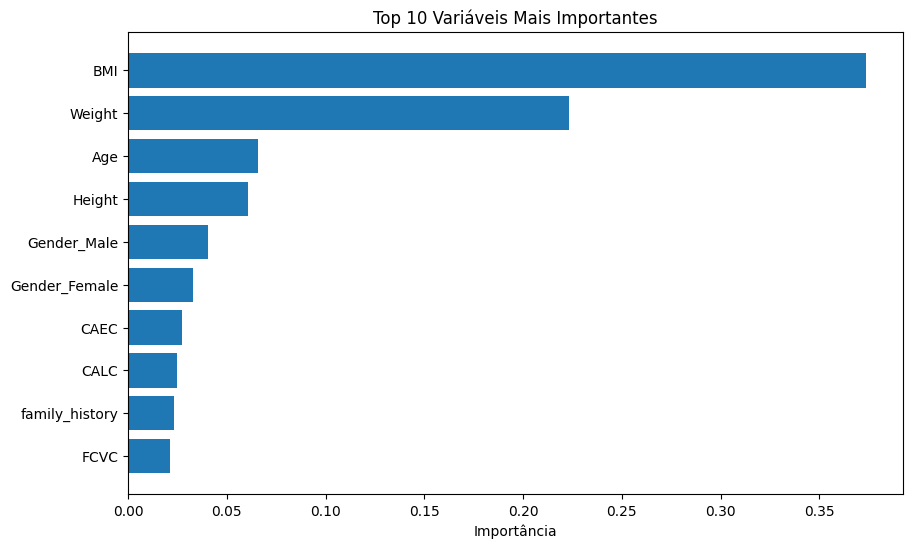

In [26]:
plt.figure(figsize=(10,6))
plt.barh(df_importancia["Variavel"][:10][::-1],
         df_importancia["Importancia"][:10][::-1])
plt.title("Top 10 Variáveis Mais Importantes")
plt.xlabel("Importância")
plt.show()

## 6. Importância das Variáveis

A análise de importância das variáveis indica que o IMC (BMI) é o principal fator preditivo do modelo, o que é coerente com a literatura médica.

Observa-se também relevância significativa das variáveis relacionadas ao peso corporal, histórico familiar e frequência de atividade física.

Esse resultado reforça a consistência clínica do modelo, uma vez que tais fatores são amplamente reconhecidos como determinantes do desenvolvimento da obesidade.

Dessa forma, o modelo não apenas apresenta alto desempenho estatístico, como também mantém coerência com fundamentos médicos.